In [1]:
from fastai.vision.all import *
import pandas as pd 

In [2]:
df = pd.read_csv("D:/SRM works/Datasets_ML/Live_project_dataset/Dataset_Info.csv")

In [4]:
df.head()

,Image ID,Pothole,Number of Potholes,Level,Unnamed: 4
0,pothole_image_1299,1,3,B,NaN
1,pothole_image_10064,1,1,A,NaN
2,pothole_image_10079,1,1,A,NaN
3,pothole_image_10084,1,1,A,NaN
4,pothole_image_10087,1,2,A,NaN


In [5]:
df = df.drop(columns=['Unnamed: 4'])

In [6]:
path = Path('D:/SRM works/Datasets_ML/Live_project_dataset/Unified Dataset/Unified Dataset')
df['image_path'] = df['Image ID'].apply(lambda x: path/(x+".jpg"))

In [7]:
df.head()

,Image ID,Pothole,Number of Potholes,Level,image_path
0,pothole_image_1299,1,3,B,D:\SRM works\Datasets_ML\Live_project_dataset\Unified Dataset\Unified Dataset\pothole_image_1299.jpg
1,pothole_image_10064,1,1,A,D:\SRM works\Datasets_ML\Live_project_dataset\Unified Dataset\Unified Dataset\pothole_image_10064.jpg
2,pothole_image_10079,1,1,A,D:\SRM works\Datasets_ML\Live_project_dataset\Unified Dataset\Unified Dataset\pothole_image_10079.jpg
3,pothole_image_10084,1,1,A,D:\SRM works\Datasets_ML\Live_project_dataset\Unified Dataset\Unified Dataset\pothole_image_10084.jpg
4,pothole_image_10087,1,2,A,D:\SRM works\Datasets_ML\Live_project_dataset\Unified Dataset\Unified Dataset\pothole_image_10087.jpg


In [8]:
df.Level.value_counts()

Level
C    23268
S     3610
A     1869
B     1253
Name: count, dtype: int64

In [9]:
df.columns

Index(['Image ID', 'Pothole', 'Number of Potholes', 'Level', 'image_path'], dtype='object')

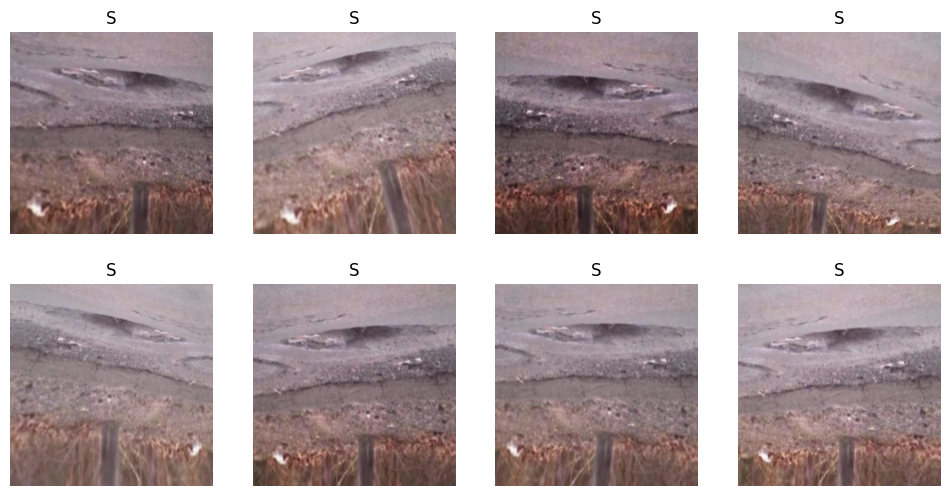

In [11]:
dblock=DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_x = ColReader('image_path'),
    get_y = ColReader('Level'),
    splitter=RandomSplitter(valid_pct=0.2,seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(
        max_rotate=10,
        max_zoom=1.1,
        max_lighting=0.2,
        flip_vert=False
    )
)
dls=dblock.dataloaders(df,bs=32)
dls.train.show_batch(max_n=8,nrows=2,unique=True)

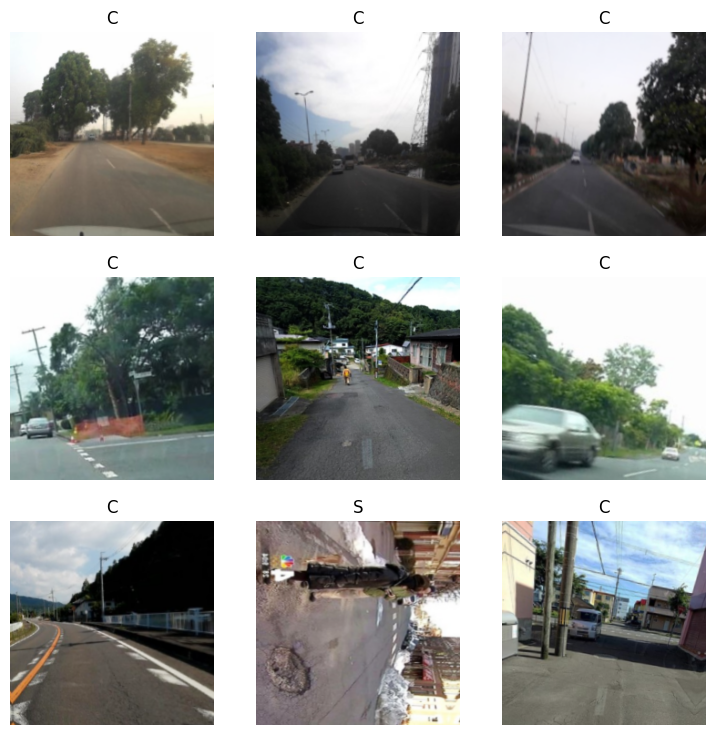

In [12]:
dls.show_batch()

epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.503424,0.406616,0.867833,0.605338,0.548975,0.573075,25:13


epoch,train_loss,valid_loss,accuracy,precision_score,recall_score,f1_score,time
0,0.352054,0.332894,0.888333,0.644047,0.574128,0.588305,06:27
1,0.334104,0.308095,0.897500,0.694868,0.553993,0.567379,04:25
2,0.298261,0.300860,0.895833,0.681451,0.613793,0.637254,04:37
3,0.263721,0.277576,0.896500,0.668117,0.643277,0.653757,04:13
4,0.217976,0.285418,0.902167,0.676940,0.650612,0.662267,04:04


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

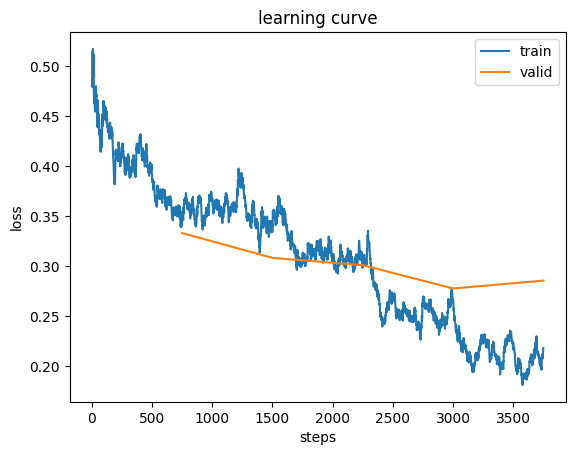

In [14]:
learn = vision_learner(
    dls,
    resnet34,
    metrics = [
        accuracy,
        Precision(average='macro'),
        Recall(average='macro'),
        F1Score(average='macro')
    ]
)
learn.fine_tune(5)
learn.recorder.plot_loss()

c:\Users\rohan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


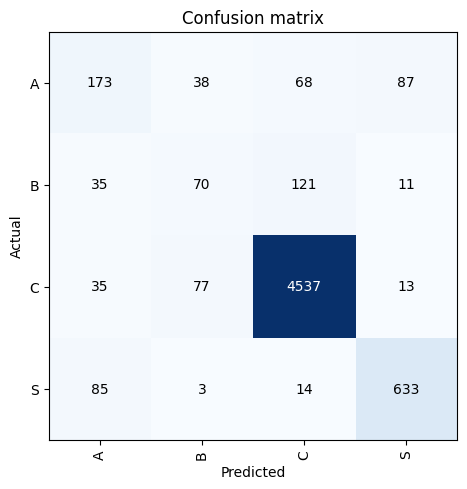

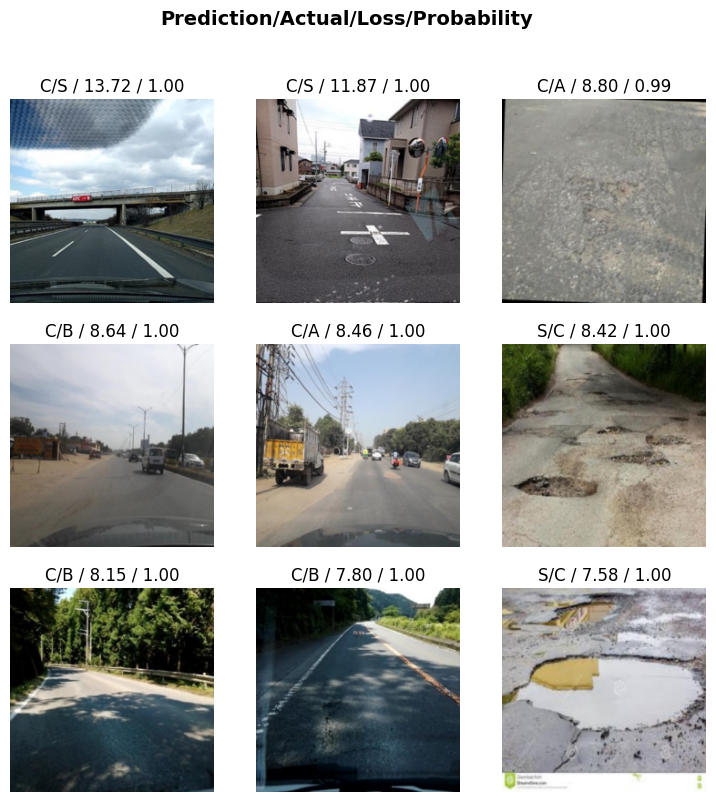

In [15]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()
interp.plot_top_losses(9)

In [16]:
learn.export('Severity_classifier.pkl')

In [18]:
learn1 = load_learner('Severity_classifier.pkl')

In [28]:
img = PILImage.create("C:/Users/rohan/Downloads/image3.jpg")

In [29]:
pred,pred_idx,probs=learn.predict(img)

print("Predicted Severity: ",pred)
print("Prediction Index: ",pred_idx)
print("Probabilities: ",probs)


<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

Predicted Severity:  S
Prediction Index:  tensor(3)
Probabilities:  tensor([0.1452, 0.0103, 0.0011, 0.8435])
